In [2]:
import pandas as pd
import numpy as np
from gurobipy import Model, GRB, LinExpr,quicksum
import re
import matplotlib.pyplot as plt

# 配置字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 指定使用的字体为“黑体”
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示为方块的问题

# 1名骑手

In [167]:
data = np.array([
    [0, 10, 10,  0,   0, 1236, 0],   # 骑手
    [1, 20, 10, 10, 448,  505, 90],  # 顾客
    [2, 10, 20, 20, 621, 702, 90],
    [3, 0, 10, -10, 912, 967, 90],  # 餐厅
    [4, 10, 0, -20, 825, 870, 90],
    [5, 0, 20,  0,   0, 1236, 0]   # 骑手
])

In [168]:
if __name__ == '__main__':
    vehicleNum = 1
    vehicleQ = 40
    n = int((data.shape[0] - 2) / 2)
    print('n =', n)
    print('data.shape[0] =', data.shape[0])

    # 计算c_ij
    c = np.zeros(shape=[data.shape[0], data.shape[0]]) # 初始化0矩阵
    for i in range(data.shape[0]):
        for j in range(data.shape[0]):
            if i != j:
                c[i, j] = ((data[i, 1] - data[j, 1]) ** 2 + (data[i, 2] - data[j, 2]) ** 2) ** 0.5
    print(c)

PDVRPTW = Model()

# 决策变量X_ijk，目标函数Minimize ∑c_ij * x_ijk
x = {}
for i in range(data.shape[0]):
    for j in range(data.shape[0]):
        for k in range(vehicleNum):
            if i != j:
                x[i, j, k] = PDVRPTW.addVar(obj=c[i, j], vtype=GRB.BINARY, name='x_' + str(i) + '_' + str(j) + '_' + str(k))

# 决策变量Q_ik
Q = {}
for i in range(data.shape[0]):
    for k in range(vehicleNum):
        Q[i, k] = PDVRPTW.addVar(lb=0, ub=vehicleQ, vtype=GRB.CONTINUOUS, name='Q_' + str(i) + '_' + str(k))

# 决策变量T_ik
T = {}
for i in range(data.shape[0]):
    for k in range(vehicleNum):
        T[i, k] = PDVRPTW.addVar(lb=0, ub=data[0, 5], vtype=GRB.CONTINUOUS, name='T_' + str(i) + '_' + str(k))

# 约束1：每个节点只服务一次
for i in range(1, n+1):
    expr1 = LinExpr(0)
    for j in range(data.shape[0]):
        for k in range(vehicleNum):
            if i != j:
                expr1.addTerms(1, x[i, j, k])
    PDVRPTW.addConstr(expr1 == 1, name='cons1' + '_' + str(i))

# 约束2：取货节点与对应送货节点由同一辆车访问
for i in range(1, n+1):
    for k in range(vehicleNum):
        expr2 = LinExpr(0)
        for j1 in range(1, data.shape[0] - 1):
            if i != j1:
                expr2.addTerms(1, x[i, j1, k])
        for j2 in range(1, data.shape[0]):
            if n+i != j2:
                expr2.addTerms(-1, x[n+i, j2, k])
        PDVRPTW.addConstr(expr2 == 0, name='cons2' + '_' + str(i) + '_' + str(k))

# 约束3：车辆驶出起始仓库
for k in range(vehicleNum):
    expr3 = LinExpr(0)
    for j in range(data.shape[0]):
        if j != 0:
            expr3.addTerms(1, x[0, j, k])
    PDVRPTW.addConstr(expr3 == 1, name='cons3' + '_' + str(k))

# 约束4：每个节点的流平衡, 即进入该节点的车辆一定从该点再出发。
for i in range(1, data.shape[0] - 1):
    for k in range(vehicleNum):
        expr4 = LinExpr(0)
        # 来点i的可能路径
        for j1 in range(0, data.shape[0] - 1):
            if i != j1 and j1 != n + i:
                expr4.addTerms(1, x[j1, i, k])
        # 离开i的可能路径
        for j2 in range(1, data.shape[0]):
            if i != j2:
                expr4.addTerms(-1, x[i, j2, k])
        PDVRPTW.addConstr(expr4 == 0, name='cons4' + '_' + str(i) + '_' + str(k))

# 约束5：车辆返回仓库
for k in range(vehicleNum):
    expr5 = LinExpr(0)
    for i in range(data.shape[0]):
        if i != 2 * n + 1:
            expr5.addTerms(1, x[i, 2 * n + 1, k])
    PDVRPTW.addConstr(expr5 == 1, name='cons5' + '_' + str(k))

# 约束6：时间, T_ik为k车到达节点i的时间，即k车开始为节点i提供服务的时间; t_ij = c_ij
for i in range(data.shape[0]):
    for j in range(data.shape[0]):
        for k in range(vehicleNum):
            if i != j:
                PDVRPTW.addConstr(T[i, k] * x[i, j, k] +
                                          data[i, 6] * x[i, j, k] +
                                          c[i, j] * x[i, j, k] -
                                          T[j, k] <= 0, name='cons6' + '_' + str(i) + '_' + str(j) + '_' + str(k))

# 约束7：负载, Q_ik是经过节点i之后车辆k的负载
for i in range(data.shape[0]):
    for j in range(data.shape[0]):
        for k in range(vehicleNum):
            if i != j:
                PDVRPTW.addConstr(Q[i, k] * x[i, j, k] +
                                          data[j, 3] * x[i, j, k] -
                                          Q[j, k] <= 0, name='cons7' + '_' + str(i) + '_' + str(j) + '_' + str(k))

for k in range(vehicleNum):
    PDVRPTW.addConstr(Q[0, k] == 0)
    PDVRPTW.addConstr(Q[data.shape[0] - 1, k] == 0)

# 约束8：先提货再送货
for i in range(1, n + 1):
    for k in range(vehicleNum):
        PDVRPTW.addConstr(-T[n + i, k] + T[i, k] + data[i, 6] + c[i, n + i] <= 0, name='cons8' + '_' + str(i) + '_' + str(k))

# 约束9：限制总时长
for k in range(vehicleNum):
    PDVRPTW.addConstr(T[2 * n + 1, k] - T[0, k] <= data[0, 5], name='cons9' + '_' + str(k))

# 约束10：时间窗约束
for i in range(data.shape[0]):
    for k in range(vehicleNum):
        PDVRPTW.addConstr(data[i, 4] - T[i, k] <= 0, name='cons10_early' + '_' + str(i) + '_' + str(k))
        PDVRPTW.addConstr(T[i, k] - data[i, 5] <= 0, name='cons10_late' + '_' + str(i) + '_' + str(k))

# 约束11：载重约束
low = {}
up = {}
for i in range(data.shape[0]):
    for k in range(vehicleNum):
        low = max(0, data[i, 3])
        up = min(vehicleQ, vehicleQ + data[i, 3])
        PDVRPTW.addConstr(-Q[i, k] + low <= 0, name='cons11_left' + '_' + str(i) + '_' + str(k))
        PDVRPTW.addConstr(Q[i, k] - up <= 0, name='cons11_right' + '_' + str(i) + '_' + str(k))

# 求解并输出模型
PDVRPTW.write("PDVRPTW.lp")
PDVRPTW.optimize()

# 获取解
for key in x.keys():
    if x[key].x > 0:
        print(x[key].VarName + ' = ', x[key].x)

for key in T.keys():
    if T[key].x > 0:
        print(T[key].VarName + ' = ', T[key].x)

for key in Q.keys():
    if Q[key].x > 0:
        print(Q[key].VarName + ' = ', Q[key].x)

n = 2
data.shape[0] = 6
[[ 0.         10.         10.         10.         10.         14.14213562]
 [10.          0.         14.14213562 20.         14.14213562 22.36067977]
 [10.         14.14213562  0.         14.14213562 20.         10.        ]
 [10.         20.         14.14213562  0.         14.14213562 10.        ]
 [10.         14.14213562 20.         14.14213562  0.         22.36067977]
 [14.14213562 22.36067977 10.         10.         22.36067977  0.        ]]
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 11.0 (22631.2))

CPU model: 13th Gen Intel(R) Core(TM) i5-1340P, instruction set [SSE2|AVX|AVX2]
Thread count: 12 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 39 rows, 42 columns and 96 nonzeros
Model fingerprint: 0x9da6a3f5
Model has 60 quadratic constraints
Variable types: 12 continuous, 30 integer (30 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  QMatrix range    [1e+00, 1e+00]
  QLMatrix ra

In [169]:
# 求解模型
PDVRPTW.optimize()

# 创建一个字典来存储解
solution_dict = {}

# 检查模型是否找到最优解
if PDVRPTW.status == GRB.OPTIMAL:
    print("Optimal solution found!")

    # 打印并保存非零决策变量的值
    print("Non-zero decision variables:")
    for i in range(all_points.shape[0]):
        for j in range(all_points.shape[0]):
            for k in range(vehicleNum):
                if (i, j, k) in x and x[i, j, k].X > 0.5:  # 遍历并筛选非零解
                    solution_dict[f'x[{i},{j},{k}]'] = x[i, j, k].X
                    print(f"x[{i},{j},{k}] = {x[i, j, k].X}")

else:
    print("No optimal solution found. Status:", PDVRPTW.status)



Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 11.0 (22631.2))

CPU model: 13th Gen Intel(R) Core(TM) i5-1340P, instruction set [SSE2|AVX|AVX2]
Thread count: 12 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 39 rows, 42 columns and 96 nonzeros
Model fingerprint: 0x9da6a3f5
Model has 60 quadratic constraints
Variable types: 12 continuous, 30 integer (30 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  QMatrix range    [1e+00, 1e+00]
  QLMatrix range   [1e+00, 1e+02]
  Objective range  [1e+01, 2e+01]
  Bounds range     [1e+00, 1e+03]
  RHS range        [1e+00, 1e+03]

MIP start from previous solve produced solution with objective 68.2843 (0.02s)
Loaded MIP start from previous solve with objective 68.2843

Presolve removed 39 rows and 42 columns
Presolve time: 0.00s
Presolve: All rows and columns removed

Explored 0 nodes (0 simplex iterations) in 0.02 seconds (0.00 work units)
Thread count was 1 (of 16 available 

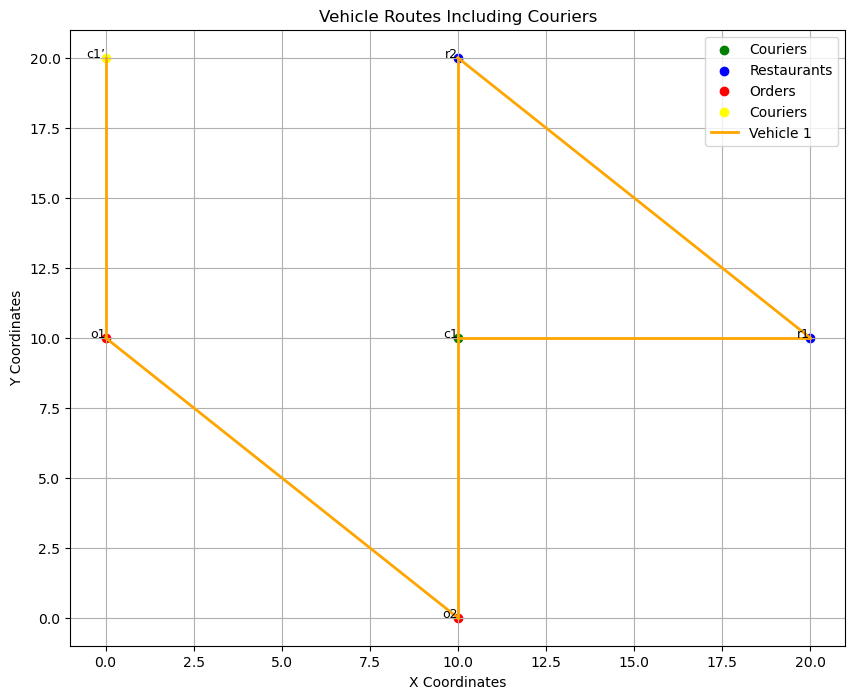

In [170]:
import matplotlib.pyplot as plt
import numpy as np

point_names = ['c1','r1','r2', 'o1','o2','c1’']        

# 提取路径信息
def extract_paths(solution, data, vehicleNum):
    paths = [[] for _ in range(vehicleNum)]
    for i in range(data.shape[0]):
        for j in range(data.shape[0]):
            for k in range(vehicleNum):
                # 从 solution_dict 中提取路径信息
                if solution.get(f'x[{i},{j},{k}]', 0) > 0.5:  # 如果有路径
                    paths[k].append((i, j))
    return paths

# 提取坐标信息（所有点的 x 和 y 坐标）
x_coords = data[:, 1]
y_coords = data[:, 2]

# 提取路径信息
paths = extract_paths(solution_dict, data, vehicleNum)

# 绘制路径图
plt.figure(figsize=(10, 8))

# 绘制所有点
plt.scatter(x_coords[:1], y_coords[:1], c='green', label='Couriers')  
plt.scatter(x_coords[1:3], y_coords[1:3], c='blue', label='Restaurants')       
plt.scatter(x_coords[3:5], y_coords[3:5], c='red', label='Orders')        
plt.scatter(x_coords[5:], y_coords[5:], c='yellow', label='Couriers')  

# 标记每个点，使用自定义的点名称
for i, (x, y) in enumerate(zip(x_coords, y_coords)):
    plt.text(x, y, f'{point_names[i]}', fontsize=9, ha='right')

# 为每辆车绘制路径
colors = ['orange', 'purple', 'cyan']  # 不同车辆的颜色
for k, path in enumerate(paths):
    for i, j in path:
        plt.plot([x_coords[i], x_coords[j]], [y_coords[i], y_coords[j]],
                 color=colors[k % len(colors)], lw=2, label=f'Vehicle {k+1}' if i == 0 else "")


# 添加图例
plt.legend()

# 显示图
plt.xlabel('X Coordinates')
plt.ylabel('Y Coordinates')
plt.title('Vehicle Routes Including Couriers')
plt.grid(True)
plt.show()


# 2名骑手

In [ ]:
data = np.array([
    [0, 10, 10,  0,   0, 1236, 0],   # 骑手
    [1, 8, 15,  0,   0, 1236, 0],   # 骑手
    [2, 20, 12, 10, 448,  505, 90],  # 餐厅
    [3, 13, 25, 20, 621, 702, 90],
    [4, 6, 13, -10, 912, 967, 90],  # 顾客
    [5, 17, 0, -20, 825, 870, 90],
    [6, 4, 2,  0,   0, 1236, 0],   # 骑手
    [7, 2, 18,  0,   0, 1236, 0]   # 骑手
])

In [129]:
if __name__ == '__main__':
    vehicleNum = 2
    vehicleQ = 40
    n = int((data.shape[0] - 4) / 2)
    print('n =', n)
    print('data.shape[0] =', data.shape[0])

    # 计算c_ij
    c = np.zeros(shape=[data.shape[0], data.shape[0]]) # 初始化0矩阵
    for i in range(data.shape[0]):
        for j in range(data.shape[0]):
            if i != j:
                c[i, j] = ((data[i, 1] - data[j, 1]) ** 2 + (data[i, 2] - data[j, 2]) ** 2) ** 0.5
    print(c)

PDVRPTW = Model()

# 决策变量X_ijk，目标函数Minimize ∑c_ij * x_ijk
x = {}
for i in range(data.shape[0]):
    for j in range(data.shape[0]):
        for k in range(vehicleNum):
            if i != j:
                x[i, j, k] = PDVRPTW.addVar(obj=c[i, j], vtype=GRB.BINARY, name='x_' + str(i) + '_' + str(j) + '_' + str(k))

# 决策变量Q_ik
Q = {}
for i in range(data.shape[0]):
    for k in range(vehicleNum):
        Q[i, k] = PDVRPTW.addVar(lb=0, ub=vehicleQ, vtype=GRB.CONTINUOUS, name='Q_' + str(i) + '_' + str(k))

# 决策变量T_ik
T = {}
for i in range(data.shape[0]):
    for k in range(vehicleNum):
        T[i, k] = PDVRPTW.addVar(lb=0, ub=data[0, 5], vtype=GRB.CONTINUOUS, name='T_' + str(i) + '_' + str(k))

# 约束1：每个节点只被服务一次
for i in range(2, data.shape[0]-2):
    expr1 = LinExpr(0)
    for j in range(data.shape[0]):
        for k in range(vehicleNum):
            if i != j:
                expr1.addTerms(1, x[i, j, k])
    PDVRPTW.addConstr(expr1 == 1, name='cons1_' + str(i))

# 约束2：取货节点与对应送货节点由同一辆车访问
for i in range(2, n+2):
    for k in range(vehicleNum):
        expr2 = LinExpr(0)
        for j1 in range(data.shape[0]):
            if i != j1:
                expr2.addTerms(1, x[i, j1, k])
        for j2 in range(data.shape[0]):
            if n+i != j2:
                expr2.addTerms(-1, x[n+i, j2, k])
        PDVRPTW.addConstr(expr2 == 0, name='cons2' + '_' + str(i) + '_' + str(k))

# 约束3：每辆车从自己的起始位置出发
for k in range(vehicleNum):
    expr3 = LinExpr(0)
    start_index = k  # 起点分别是 data[0] 和 data[1]
    for j in range(data.shape[0]):
        if j != start_index:
            expr3.addTerms(1, x[start_index, j, k])
    PDVRPTW.addConstr(expr3 == 1, name='cons3_' + str(k))

# 约束4：每个节点的流平衡, 即进入该节点的车辆一定从该点再出发
for i in range(2, data.shape[0] - 2):
    for k in range(vehicleNum):
        expr4 = LinExpr(0)
        # 来点i的可能路径
        for j1 in range(0, data.shape[0] - 2):
            if i != j1 and j1 != n + i:
                expr4.addTerms(1, x[j1, i, k])
        # 离开i的可能路径
        for j2 in range(2, data.shape[0]):
            if i != j2:
                expr4.addTerms(-1, x[i, j2, k])
        PDVRPTW.addConstr(expr4 == 0, name='cons4' + '_' + str(i) + '_' + str(k))

# 约束5：每辆车返回自己的终点
for k in range(vehicleNum):
    expr5 = LinExpr(0)
    end_index = data.shape[0] - vehicleNum + k  # 终点分别是 data[6] 和 data[7]
    for i in range(0,data.shape[0]):
        if i != end_index:
            expr5.addTerms(1, x[i, end_index, k])
    PDVRPTW.addConstr(expr5 == 1, name='cons5_' + str(k))


# 约束6：时间, T_ik为k车到达节点i的时间，即k车开始为节点i提供服务的时间; t_ij = c_ij
for i in range(data.shape[0]):
    for j in range(data.shape[0]):
        for k in range(vehicleNum):
            if i != j:
                PDVRPTW.addConstr(T[i, k] * x[i, j, k] +
                                          data[i, 6] * x[i, j, k] +
                                          c[i, j] * x[i, j, k] -
                                          T[j, k] <= 0, name='cons6' + '_' + str(i) + '_' + str(j) + '_' + str(k))

# 约束7：负载, Q_ik是经过节点i之后车辆k的负载
for i in range(data.shape[0]):
    for j in range(data.shape[0]):
        for k in range(vehicleNum):
            if i != j:
                PDVRPTW.addConstr(Q[i, k] * x[i, j, k] +
                                          data[j, 3] * x[i, j, k] -
                                          Q[j, k] <= 0, name='cons7' + '_' + str(i) + '_' + str(j) + '_' + str(k))

for k in range(vehicleNum):
    PDVRPTW.addConstr(Q[0, k] == 0)
    PDVRPTW.addConstr(Q[1, k] == 0)
    PDVRPTW.addConstr(Q[data.shape[0]-2, k] == 0)
    PDVRPTW.addConstr(Q[data.shape[0]-1, k] == 0)

# 约束8：先提货再送货
for i in range(2, n+2):
    for k in range(vehicleNum):
        PDVRPTW.addConstr(-T[n + i, k] + T[i, k] + data[i, 6] + c[i, n + i] <= 0, name='cons8' + '_' + str(i) + '_' + str(k))

# 约束9：限制每辆车的总时间
for k in range(vehicleNum):
    start_index = k
    end_index = data.shape[0] - vehicleNum + k
    PDVRPTW.addConstr(T[end_index, k] - T[start_index, k] <= data[start_index, 5], name='cons9_' + str(k))

# 约束10：时间窗约束
for i in range(data.shape[0]):
    for k in range(vehicleNum):
        PDVRPTW.addConstr(data[i, 4] - T[i, k] <= 0, name='cons10_early' + '_' + str(i) + '_' + str(k))
        PDVRPTW.addConstr(T[i, k] - data[i, 5] <= 0, name='cons10_late' + '_' + str(i) + '_' + str(k))

# 约束11：载重约束
low = {}
up = {}
for i in range(data.shape[0]):
    for k in range(vehicleNum):
        low = max(0, data[i, 3])
        up = min(vehicleQ, vehicleQ + data[i, 3])
        PDVRPTW.addConstr(-Q[i, k] + low <= 0, name='cons11_left' + '_' + str(i) + '_' + str(k))
        PDVRPTW.addConstr(Q[i, k] - up <= 0, name='cons11_right' + '_' + str(i) + '_' + str(k))

# 求解并输出模型
PDVRPTW.write("PDVRPTW.lp")
PDVRPTW.optimize()

# 获取解
for key in x.keys():
    if x[key].x > 0:
        print(x[key].VarName + ' = ', x[key].x)

for key in T.keys():
    if T[key].x > 0:
        print(T[key].VarName + ' = ', T[key].x)

for key in Q.keys():
    if Q[key].x > 0:
        print(Q[key].VarName + ' = ', Q[key].x)

n = 2
data.shape[0] = 8
[[ 0.          5.38516481 10.19803903 15.29705854  5.         12.20655562
  10.         11.3137085 ]
 [ 5.38516481  0.         12.36931688 11.18033989  2.82842712 17.49285568
  13.60147051  6.70820393]
 [10.19803903 12.36931688  0.         14.76482306 14.03566885 12.36931688
  18.86796226 18.97366596]
 [15.29705854 11.18033989 14.76482306  0.         13.89244399 25.3179778
  24.69817807 13.03840481]
 [ 5.          2.82842712 14.03566885 13.89244399  0.         17.02938637
  11.18033989  6.40312424]
 [12.20655562 17.49285568 12.36931688 25.3179778  17.02938637  0.
  13.15294644 23.43074903]
 [10.         13.60147051 18.86796226 24.69817807 11.18033989 13.15294644
   0.         16.1245155 ]
 [11.3137085   6.70820393 18.97366596 13.03840481  6.40312424 23.43074903
  16.1245155   0.        ]]
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 11.0 (22631.2))

CPU model: 13th Gen Intel(R) Core(TM) i5-1340P, instruction set [SSE2|AVX|AVX2]
Thread count:

In [130]:
# 求解模型
PDVRPTW.optimize()

# 创建一个字典来存储解
solution_dict = {}

# 检查模型是否找到最优解
if PDVRPTW.status == GRB.OPTIMAL:
    print("Optimal solution found")

    # 打印并保存非零决策变量的值
    print("Non-zero decision variables:")
    for i in range(data.shape[0]):
        for j in range(data.shape[0]):
            for k in range(vehicleNum):
                if (i, j, k) in x and x[i, j, k].X > 0.5:  # 遍历并筛选非零解
                    solution_dict[f'x[{i},{j},{k}]'] = x[i, j, k].X
                    print(f"x[{i},{j},{k}] = {x[i, j, k].X}")

else:
    print("No optimal solution found. Status:", PDVRPTW.status)


Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 11.0 (22631.2))

CPU model: 13th Gen Intel(R) Core(TM) i5-1340P, instruction set [SSE2|AVX|AVX2]
Thread count: 12 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 98 rows, 144 columns and 300 nonzeros
Model fingerprint: 0x2bf849de
Model has 224 quadratic constraints
Variable types: 32 continuous, 112 integer (112 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  QMatrix range    [1e+00, 1e+00]
  QLMatrix range   [1e+00, 1e+02]
  Objective range  [3e+00, 3e+01]
  Bounds range     [1e+00, 1e+03]
  RHS range        [1e+00, 1e+03]
Presolved: 178 rows, 186 columns, 576 nonzeros
Presolved model has 48 SOS constraint(s)

Continuing optimization...


Explored 1 nodes (25 simplex iterations) in 0.03 seconds (0.00 work units)
Thread count was 16 (of 16 available processors)

Solution count 4: 85.1988 85.8846 86.5761 103.284 

Optimal solution found (tolerance 1.00e-04)
Best obj

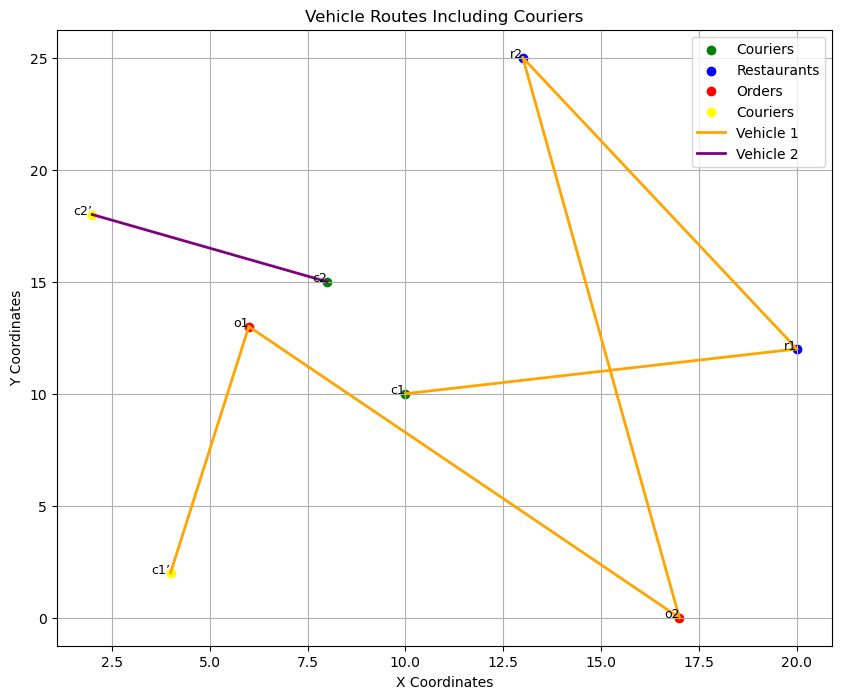

In [132]:
import matplotlib.pyplot as plt
import numpy as np

point_names = ['c1','c2','r1','r2', 'o1','o2','c1’','c2’']        

# 提取路径信息
def extract_paths(solution, data, vehicleNum):
    paths = [[] for _ in range(vehicleNum)]
    for i in range(data.shape[0]):
        for j in range(data.shape[0]):
            for k in range(vehicleNum):
                # 从 solution_dict 中提取路径信息
                if solution.get(f'x[{i},{j},{k}]', 0) > 0.5:  # 如果有路径
                    paths[k].append((i, j))
    return paths

# 提取坐标信息（所有点的 x 和 y 坐标）
x_coords = data[:, 1]
y_coords = data[:, 2]

# 提取路径信息
paths = extract_paths(solution_dict, data, vehicleNum)

# 绘制路径图
plt.figure(figsize=(10, 8))

# 绘制所有点
plt.scatter(x_coords[:2], y_coords[:2], c='green', label='Couriers')  
plt.scatter(x_coords[2:4], y_coords[2:4], c='blue', label='Restaurants')       
plt.scatter(x_coords[4:6], y_coords[4:6], c='red', label='Orders')        
plt.scatter(x_coords[6:], y_coords[6:], c='yellow', label='Couriers')  

# 标记每个点，使用自定义的点名称
for i, (x, y) in enumerate(zip(x_coords, y_coords)):
    plt.text(x, y, f'{point_names[i]}', fontsize=9, ha='right')

# 为每辆车绘制路径
colors = ['orange', 'purple', 'cyan']  # 不同车辆的颜色
for k, path in enumerate(paths):
    for i, j in path:
        plt.plot([x_coords[i], x_coords[j]], [y_coords[i], y_coords[j]],
                 color=colors[k % len(colors)], lw=2, label=f'Vehicle {k+1}' if j == path[0][1] else "")

# 添加图例
plt.legend()

# 显示图
plt.xlabel('X Coordinates')
plt.ylabel('Y Coordinates')
plt.title('Vehicle Routes Including Couriers')
plt.grid(True)
plt.show()


# 多名骑手

In [113]:
data = np.array([
    [0, 13, 14,  0,   0, 1236, 0],   # 骑手
    [1, 15, 19,  0,   0, 1236, 0],   # 骑手
    [2, 19, 12,  0,   0, 1236, 0],   # 骑手
    [3, 20, 12, 10, 448,  505, 90],  # 餐厅
    [4, 13, 8, 20, 621, 702, 90],   # 餐厅
    [5, 16, 13, 10, 648, 705, 90], # 餐厅
    [6, 18, 18, 20, 821, 902, 90], # 餐厅
    [7, 18, 15, -10, 912, 967, 90],  # 顾客
    [8, 12, 12, -20, 825, 870, 90],  # 顾客
    [9, 15, 10, -10, 1012, 1067, 90],  # 顾客
    [10, 17, 13, -20, 1025, 1070, 90], # 顾客
    [11, 17, 9,  0,   0, 1236, 0],   # 骑手
    [12, 11, 16,  0,   0, 1236, 0],   # 骑手
    [13, 17, 11,  0,   0, 1236, 0]   # 骑手
])

In [114]:
vehicleNum = 3
vehicleQ = 60
n = int((data.shape[0] - 6) / 2)
print('n =', n)
print('data.shape[0] =', data.shape[0])

# 计算c_ij
c = np.zeros(shape=[data.shape[0], data.shape[0]]) # 初始化0矩阵
for i in range(data.shape[0]):
    for j in range(data.shape[0]):
        if i != j:
            c[i, j] = ((data[i, 1] - data[j, 1]) ** 2 + (data[i, 2] - data[j, 2]) ** 2) ** 0.5
print(c)

PDVRPTW = Model()

# 决策变量X_ijk，目标函数Minimize ∑c_ij * x_ijk
x = {}
for i in range(data.shape[0]):
    for j in range(data.shape[0]):
        for k in range(vehicleNum):
            if i != j:
                x[i, j, k] = PDVRPTW.addVar(obj=c[i, j], vtype=GRB.BINARY, name='x_' + str(i) + '_' + str(j) + '_' + str(k))

# 决策变量Q_ik
Q = {}
for i in range(data.shape[0]):
    for k in range(vehicleNum):
        Q[i, k] = PDVRPTW.addVar(lb=0, ub=vehicleQ, vtype=GRB.CONTINUOUS, name='Q_' + str(i) + '_' + str(k))

# 决策变量T_ik
T = {}
for i in range(data.shape[0]):
    for k in range(vehicleNum):
        T[i, k] = PDVRPTW.addVar(lb=0, ub=data[0, 5], vtype=GRB.CONTINUOUS, name='T_' + str(i) + '_' + str(k))

# 约束1：每个节点只被服务一次
for i in range(3, n+3):
    expr1 = LinExpr(0)
    for j in range(data.shape[0]):
        for k in range(vehicleNum):
            if i != j:
                expr1.addTerms(1, x[i, j, k])
    PDVRPTW.addConstr(expr1 == 1, name='cons1_' + str(i))

# 约束2：取货节点与对应送货节点由同一辆车访问
for i in range(3, n+3):
    for k in range(vehicleNum):
        expr2 = LinExpr(0)
        for j1 in range(3,data.shape[0]-3):
            if i != j1:
                expr2.addTerms(1, x[i, j1, k])
        for j2 in range(3,data.shape[0]):
            if n+i != j2:
                expr2.addTerms(-1, x[n+i, j2, k])
        PDVRPTW.addConstr(expr2 == 0, name='cons2' + '_' + str(i) + '_' + str(k))

# 约束3：每辆车从自己的起始位置出发
for k in range(vehicleNum):
    start_index = k  # 每辆车的起点索引
    PDVRPTW.addConstr(
        quicksum(x[start_index, j, k] for j in range(data.shape[0]) if j != start_index) == 1, name = 'cons3_unique' + str(k))
    # 确保其他车辆不能从该起点出发
    for other_k in range(vehicleNum):
        if other_k != k:
            PDVRPTW.addConstr(
                quicksum(x[start_index, j, other_k] for j in range(data.shape[0]) if j != start_index) == 0, name='cons3_exclusive_' + str(k) + '_' + str(other_k))

# 约束4：每个节点的流平衡, 即进入该节点的车辆一定从该点再出发
for i in range(3, data.shape[0] - 3):
    for k in range(vehicleNum):
        expr4 = LinExpr(0)
        # 来点i的可能路径
        for j1 in range(0, data.shape[0] - 3):
            if i != j1 and j1 != n + i:
                expr4.addTerms(1, x[j1, i, k])
        # 离开i的可能路径
        for j2 in range(3, data.shape[0]):
            if i != j2:
                expr4.addTerms(-1, x[i, j2, k])
        PDVRPTW.addConstr(expr4 == 0, name='cons4' + '_' + str(i) + '_' + str(k))

# 约束5：每辆车返回自己的终点
for k in range(vehicleNum):
    end_index = data.shape[0] - vehicleNum + k  # 每辆车的终点索引
    PDVRPTW.addConstr(
        quicksum(x[i, end_index, k] for i in range(data.shape[0]) if i != end_index) == 1,  name = 'cons5_unique' + str(k))
    # 确保其他车辆不能到达该终点
    for other_k in range(vehicleNum):
        if other_k != k:
            PDVRPTW.addConstr(
                quicksum(x[i, end_index, other_k] for i in range(data.shape[0]) if i != end_index) == 0,name='cons5_exclusive_' + str(k) + '_' + str(other_k))

# 约束6：时间, T_ik为k车到达节点i的时间，即k车开始为节点i提供服务的时间; t_ij = c_ij
for i in range(data.shape[0]):
    for j in range(data.shape[0]):
        for k in range(vehicleNum):
            if i != j:
                PDVRPTW.addConstr(T[i, k] * x[i, j, k] +
                                          data[i, 6] * x[i, j, k] +
                                          c[i, j] * x[i, j, k] -
                                          T[j, k] <= 0, name='cons6' + '_' + str(i) + '_' + str(j) + '_' + str(k))

# 约束7：负载, Q_ik是经过节点i之后车辆k的负载
for i in range(data.shape[0]):
    for j in range(data.shape[0]):
        for k in range(vehicleNum):
            if i != j:
                PDVRPTW.addConstr(Q[i, k] * x[i, j, k] +
                                          data[j, 3] * x[i, j, k] -
                                          Q[j, k] <= 0, name='cons7' + '_' + str(i) + '_' + str(j) + '_' + str(k))

for k in range(vehicleNum):
    PDVRPTW.addConstr(Q[0, k] == 0)
    PDVRPTW.addConstr(Q[1, k] == 0)
    PDVRPTW.addConstr(Q[2, k] == 0)
    PDVRPTW.addConstr(Q[data.shape[0]-3, k] == 0)
    PDVRPTW.addConstr(Q[data.shape[0]-2, k] == 0)
    PDVRPTW.addConstr(Q[data.shape[0]-1, k] == 0)

# 约束8：先提货再送货
for i in range(3, n+3):
    for k in range(vehicleNum):
        PDVRPTW.addConstr(-T[n + i, k] + T[i, k] + data[i, 6] + c[i, n + i] <= 0, name='cons8' + '_' + str(i) + '_' + str(k))

# 约束9：限制每辆车的总时间
for k in range(vehicleNum):
    start_index = k
    end_index = data.shape[0] - vehicleNum + k
    PDVRPTW.addConstr(T[end_index, k] - T[start_index, k] <= data[start_index, 5], name='cons9_' + str(k))

# 约束10：时间窗约束
for i in range(data.shape[0]):
    for k in range(vehicleNum):
        PDVRPTW.addConstr(data[i, 4] - T[i, k] <= 0, name='cons10_early' + '_' + str(i) + '_' + str(k))
        PDVRPTW.addConstr(T[i, k] - data[i, 5] <= 0, name='cons10_late' + '_' + str(i) + '_' + str(k))

# 约束11：载重约束
low = {}
up = {}
for i in range(data.shape[0]):
    for k in range(vehicleNum):
        low = max(0, data[i, 3])
        up = min(vehicleQ, vehicleQ + data[i, 3])
        PDVRPTW.addConstr(-Q[i, k] + low <= 0, name='cons11_left' + '_' + str(i) + '_' + str(k))
        PDVRPTW.addConstr(Q[i, k] - up <= 0, name='cons11_right' + '_' + str(i) + '_' + str(k))

        
# 求解模型
PDVRPTW.optimize()

# 获取解
for key in x.keys():
    if x[key].x > 0:
        print(x[key].VarName + ' = ', x[key].x)

for key in T.keys():
    if T[key].x > 0:
        print(T[key].VarName + ' = ', T[key].x)

for key in Q.keys():
    if Q[key].x > 0:
        print(Q[key].VarName + ' = ', Q[key].x)

n = 4
data.shape[0] = 14
[[ 0.          5.38516481  6.32455532  7.28010989  6.          3.16227766
   6.40312424  5.09901951  2.23606798  4.47213595  4.12310563  6.40312424
   2.82842712  5.        ]
 [ 5.38516481  0.          8.06225775  8.60232527 11.18033989  6.08276253
   3.16227766  5.          7.61577311  9.          6.32455532 10.19803903
   5.          8.24621125]
 [ 6.32455532  8.06225775  0.          1.          7.21110255  3.16227766
   6.08276253  3.16227766  7.          4.47213595  2.23606798  3.60555128
   8.94427191  2.23606798]
 [ 7.28010989  8.60232527  1.          0.          8.06225775  4.12310563
   6.32455532  3.60555128  8.          5.38516481  3.16227766  4.24264069
   9.8488578   3.16227766]
 [ 6.         11.18033989  7.21110255  8.06225775  0.          5.83095189
  11.18033989  8.60232527  4.12310563  2.82842712  6.40312424  4.12310563
   8.24621125  5.        ]
 [ 3.16227766  6.08276253  3.16227766  4.12310563  5.83095189  0.
   5.38516481  2.82842712  4.12310

In [115]:
# 求解模型
PDVRPTW.optimize()

# 创建一个字典来存储解
solution_dict = {}

# 检查模型是否找到最优解
if PDVRPTW.status == GRB.OPTIMAL:
    print("Optimal solution found")

    # 打印并保存非零决策变量的值
    print("Non-zero decision variables:")
    for i in range(data.shape[0]):
        for j in range(data.shape[0]):
            for k in range(vehicleNum):
                if (i, j, k) in x and x[i, j, k].X > 0.5:  # 遍历并筛选非零解
                    solution_dict[f'x[{i},{j},{k}]'] = x[i, j, k].X
                    print(f"x[{i},{j},{k}] = {x[i, j, k].X}")

else:
    print("No optimal solution found. Status:", PDVRPTW.status)


Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 11.0 (22631.2))

CPU model: 13th Gen Intel(R) Core(TM) i5-1340P, instruction set [SSE2|AVX|AVX2]
Thread count: 12 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 259 rows, 630 columns and 1278 nonzeros
Model fingerprint: 0x78edb8f8
Model has 1092 quadratic constraints
Variable types: 84 continuous, 546 integer (546 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  QMatrix range    [1e+00, 1e+00]
  QLMatrix range   [1e+00, 1e+02]
  Objective range  [1e+00, 1e+01]
  Bounds range     [1e+00, 1e+03]
  RHS range        [1e+00, 1e+03]
Presolved: 391 rows, 384 columns, 1103 nonzeros
Presolved model has 84 SOS constraint(s)

Continuing optimization...


Explored 1 nodes (19 simplex iterations) in 0.02 seconds (0.00 work units)
Thread count was 16 (of 16 available processors)

Solution count 3: 42.5478 47.5468 51.865 

Optimal solution found (tolerance 1.00e-04)
Best objectiv

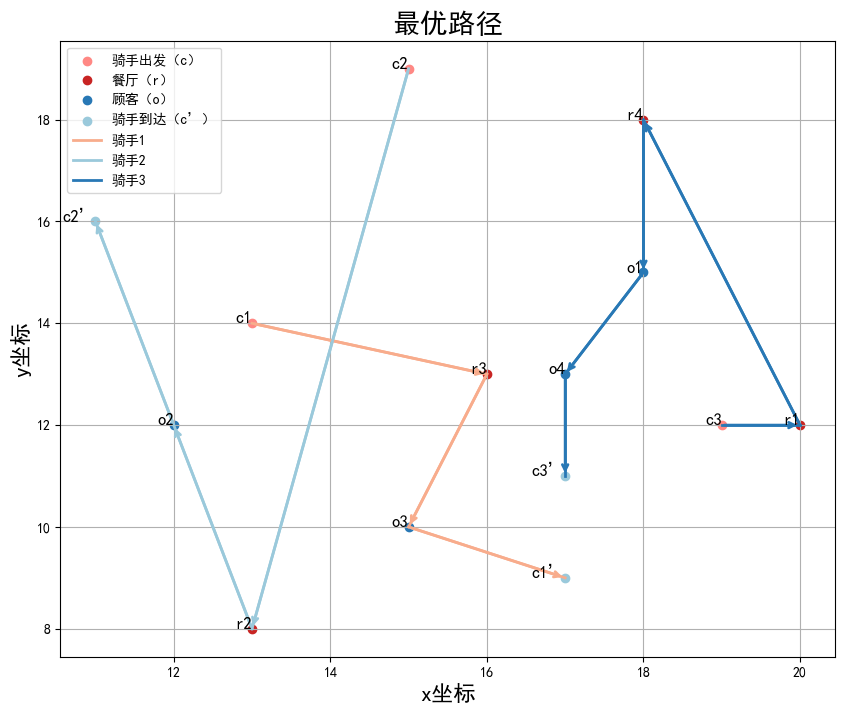

In [116]:
point_names = ['c1', 'c2', 'c3', 'r1', 'r2', 'r3', 'r4', 'o1', 'o2', 'o3', 'o4', 'c1’', 'c2’', 'c3’']

# 提取路径信息
def extract_paths(solution, data, vehicleNum):
    paths = [[] for _ in range(vehicleNum)]
    for i in range(data.shape[0]):
        for j in range(data.shape[0]):
            for k in range(vehicleNum):
                # 从 solution_dict 中提取路径信息
                if solution.get(f'x[{i},{j},{k}]', 0) > 0.5:  # 如果有路径
                    paths[k].append((i, j))
    return paths

# 提取坐标信息（所有点的 x 和 y 坐标）
x_coords = data[:, 1]
y_coords = data[:, 2]

# 提取路径信息
paths = extract_paths(solution_dict, data, vehicleNum)

# 绘制路径图
plt.figure(figsize=(10, 8))

# 绘制所有点
plt.scatter(x_coords[:3], y_coords[:3], c='#FF8884', label='骑手出发（c）')  
plt.scatter(x_coords[3:7], y_coords[3:7], c='#C82423', label='餐厅（r）')       
plt.scatter(x_coords[7:11], y_coords[7:11], c='#2878B5', label='顾客（o）')        
plt.scatter(x_coords[11:], y_coords[11:], c='#9AC9DB', label='骑手到达（c’）')  


# 为每辆车绘制路径，并添加箭头
colors = ['#F8AC8C', '#9AC9DB', '#2878B5']  # 不同车辆的颜色
for k, path in enumerate(paths):
    for i, j in path:
        # 绘制路径线
        plt.plot([x_coords[i], x_coords[j]], [y_coords[i], y_coords[j]],
                 color=colors[k % len(colors)], lw=2, label=f'骑手{k+1}' if j == path[0][1] else "")
        
        # 在路径上添加箭头，显示方向
        plt.annotate('', xy=(x_coords[j], y_coords[j]), xytext=(x_coords[i], y_coords[i]),
                     arrowprops=dict(arrowstyle='->', color=colors[k % len(colors)], lw=2))

# 标记每个点，使用自定义的点名称
for i, (x, y) in enumerate(zip(x_coords, y_coords)):
    plt.text(x, y, f'{point_names[i]}', fontsize=12, ha='right')

# 添加图例
plt.legend()

# 显示图
plt.xlabel('x坐标', fontsize=16)
plt.ylabel('y坐标', fontsize=16)
plt.title('最优路径', fontsize=20)
plt.grid(True)
plt.show()
